<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-sEEG-core-of-epilepsy/blob/main/sEEG_blind_vs_targeted_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Case study: blind vs. targeted seizure detection, and why data hygiene changes the verdict

This notebook is a focused case study built on `dataset/sEEG-HFOs-8.edf`, isolating one specific, checkable claim into its own artifact (companion notebooks:
[`sEEG_extreme_event_detector_colab.ipynb`](sEEG_extreme_event_detector_colab.ipynb) runs the full 5-method ensemble at production resolution; the installable `extreme_event_agent` package documents the same finding for its own lighter blind fallback).

**Data hygiene note (read first):** after ≈10550 s this recording contains a surgical cauterization procedure, not brain activity. Every analysis below is restricted to 0–10550 s (Sections 2–3) for that reason. This exclusion changes the outcome substantially compared to scanning the raw file end to end — see Section 6.

**The claim, in three parts, on the cleaned (0–10550 s) recording:**

1. **A purely blind, broadband statistical ensemble does cross its own automatic outlier threshold near this seizure (`detected=True`) — but late and coarse.** Its recording-wide maximum lands 39.6 s after the clinically annotated onset, most likely on the seizure's own convulsive/tonic-clonic phase rather than the onset itself, and it gives no indication of frequency band or which contacts are involved.
2. **That late, coarse detection is not the same failure mode the raw (uncropped) file produces.** Scanning the full ≈3.9 h recording, including the post-seizure cauterization segment, gives `detected=False`: the recording-wide maximum sits *inside* the cauterization segment itself (10584 s — a non-physiological artifact, not brain activity), and that same segment inflates the recording's own median/MAD baseline enough to push the automatic threshold above the genuine seizure-related excursion. Excluding the non-brain segment removes both effects at once.
3. **A frequency-band-*targeted* method still finds it far more precisely.** Restricting the same kind of energy-based analysis to the clinically motivated 13–80 Hz (beta/gamma) band, and reading the time to look *from the recording's own EDF+ annotation* (not a blind guess), reveals a sharp, spatially coherent recruitment across 98 of 100 contacts within seconds of the annotated onset — far tighter in time, and far more informative about which channels are involved, than the blind ensemble's ~40 s-late, single-number verdict.

> **Important:** none of this is a diagnosis. It is a methods comparison on one recording, meant to make an applicability boundary explicit, not to claim either method works in general.


## 1. Install and import dependencies


In [25]:
%pip install -q "mne>=1.6" "edfio>=0.4" "numpy>=1.23" "pandas>=1.5" "matplotlib>=3.7" "scipy>=1.10" "PyWavelets>=1.5" "numba>=0.58"


Note: you may need to restart the kernel to use updated packages.


In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pywt
from numba import njit, prange
from scipy.signal import butter, hilbert, sosfiltfilt

mne.set_log_level("WARNING")
plt.rcParams.update({"figure.figsize": (16, 6), "axes.spines.top": False,
                     "axes.spines.right": False})


## 2. Configuration

The blind-ensemble settings (window size, threshold, method set) mirror `sEEG_extreme_event_detector_colab.ipynb`, with a coarser, non-overlapping step for tractable runtime here. One deliberate difference from that companion notebook: this notebook crops the recording to `ANALYSIS_END_SECONDS` (Section 3) before any analysis, excluding a post-seizure surgical segment that is not brain activity — so this notebook's blind-ensemble numbers are not directly comparable to a companion analysis that scans the file end to end.


In [27]:
EDF_NAME = "sEEG-HFOs-8.edf"
# After ~10550 s this recording contains a surgical cauterization procedure, not brain
# activity (confirmed by inspection of the traces). It is excluded from every analysis
# below by cropping the raw data at load time (Section 3), so only 0-10550 s is ever
# read, filtered, or scored downstream.
ANALYSIS_END_SECONDS = 10550.0
WINDOW_SECONDS = 4.0
# Non-overlapping (STEP == WINDOW): far cheaper than the companion detector notebook's
# overlapping 0.5 s step, while still sampling every WINDOW_SECONDS-aligned instant in
# the (now cropped) analysis range.
STEP_SECONDS = 4.0
CHANNEL_FRACTION = 0.10
THRESHOLD_MAD = 6.0
MERGE_GAP_SECONDS = 1.0
METHOD_SAMPLES = 64
DTW_RADIUS = 8
ZOOM_PADDING_SECONDS = 60.0     # context around the two moments in the Part 1 figure
TARGETED_BASELINE_SECONDS = 30.0  # pre-event baseline for the Part 3 beta/gamma z-score
TARGETED_ANALYSIS_SECONDS = 10.0  # post-event window for the Part 3 beta/gamma z-score
MAX_PLOT_CHANNELS = 40           # cap on channels drawn in the Part 3 heatmap

OUTPUT_DIR = Path("/content") if Path("/content").is_dir() else Path.cwd() / "seeg_agent_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert WINDOW_SECONDS > 0 and 0 < STEP_SECONDS <= WINDOW_SECONDS
assert 0 < CHANNEL_FRACTION <= 1 and THRESHOLD_MAD > 0
assert METHOD_SAMPLES >= 32 and 1 <= DTW_RADIUS < METHOD_SAMPLES
assert ANALYSIS_END_SECONDS > 0


## 3. Load the EDF


In [28]:
candidates = [
    Path("/content") / EDF_NAME,
    Path("/content/dataset") / EDF_NAME,
    Path.cwd() / EDF_NAME,
    Path.cwd() / "dataset" / EDF_NAME,
]
edf_path = next((path for path in candidates if path.is_file()), None)

if edf_path is None:
    try:
        from google.colab import files
    except ImportError as exc:
        searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
        raise FileNotFoundError(f"{EDF_NAME} was not found. Searched:\n{searched}") from exc
    print(f"Select {EDF_NAME} in the upload dialog.")
    uploaded = files.upload()
    if EDF_NAME not in uploaded:
        raise FileNotFoundError(f"The uploaded file must be named {EDF_NAME!r}.")
    edf_path = Path("/content") / EDF_NAME

# cp1251 (Windows-1251 Cyrillic): this file's EDF+ annotations are Cyrillic; MNE's default
# UTF-8 decode raises on them. cp1251 also decodes the plain-ASCII channel names correctly.
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING", encoding="cp1251")

# Crop out the post-cauterization segment (see ANALYSIS_END_SECONDS, Section 2) before
# anything else touches `raw`, so every downstream cell -- feature extraction, the blind
# ensemble, the targeted beta/gamma scan -- only ever sees brain activity. tmin=0 keeps
# raw.first_samp at 0, so sample indices and the EDF's own annotation onsets used later
# (Section 4) stay aligned to the same absolute time axis as before cropping.
full_duration_s = raw.n_times / float(raw.info["sfreq"])
crop_end_s = min(ANALYSIS_END_SECONDS, full_duration_s)
excluded_s = full_duration_s - crop_end_s
raw.crop(tmin=0.0, tmax=crop_end_s)

marker_channels = [name for name in raw.ch_names if name.strip().upper().startswith("MKR")]
signal_channels = [name for name in raw.ch_names if name not in marker_channels]
if not signal_channels:
    raise ValueError("No non-MKR channels remain.")

sfreq = float(raw.info["sfreq"])
duration_s = raw.n_times / sfreq
print(f"Loaded: {edf_path}")
print(f"Full recording duration: {full_duration_s:.3f} s | sampling rate: {sfreq:g} Hz")
if excluded_s > 0:
    print(f"Excluded post-cauterization segment: {crop_end_s:.1f}-{full_duration_s:.1f} s "
          f"({excluded_s:.1f} s / {excluded_s / 60:.1f} min) -- surgical procedure, not brain activity.")
print(f"Analysis range after crop: 0-{duration_s:.3f} s")
print(f"Analyzing all {len(signal_channels)} non-MKR channels "
      f"(excluded {len(marker_channels)}: {marker_channels or 'none'})")


Loaded: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/dataset/sEEG-HFOs-8.edf
Full recording duration: 14095.000 s | sampling rate: 256 Hz
Excluded post-cauterization segment: 10550.0-14095.0 s (3545.0 s / 59.1 min) -- surgical procedure, not brain activity.
Analysis range after crop: 0-10550.004 s
Analyzing all 100 non-MKR channels (excluded 2: ['MKR1+', 'MKR2+'])


/var/folders/57/nnp0s5hs27d65fbf6n2frbjh0000gn/T/ipykernel_56976/1254317633.py:23: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING", encoding="cp1251")


## 4. Locate the EDF's own annotated event (no apriori time)

Read directly from the file's own EDF+ annotation channel — the clinician's real-time markup, embedded in the recording, not a number typed into this notebook. Matched by keyword (`SEIZURE_KEYWORDS`) and clustered so the clinician's separate notes about the same seizure (an "onset?" query beside a "seizure" tag) read as one event, not three unrelated ones.


In [29]:
SEIZURE_KEYWORDS = ("\u043f\u0440\u0438\u0441\u0442\u0443\u043f", "\u0441\u0443\u0434\u043e\u0440\u043e\u0433", "seizure", "ictal", "\u0431\u0442\u043a\u043f", "tcs")
ANNOTATION_CLUSTER_GAP_SECONDS = 10.0

annotation_onsets = [float(onset) for onset in raw.annotations.onset]
annotation_descriptions = [str(description) for description in raw.annotations.description]


def cluster_seizure_annotation(onsets, descriptions):
    matches = {index for index, description in enumerate(descriptions)
              if any(keyword in description.lower() for keyword in SEIZURE_KEYWORDS)}
    if not matches:
        return None
    order = sorted(range(len(onsets)), key=lambda index: onsets[index])
    groups = [[order[0]]]
    for index in order[1:]:
        if onsets[index] - onsets[groups[-1][-1]] <= ANNOTATION_CLUSTER_GAP_SECONDS:
            groups[-1].append(index)
        else:
            groups.append([index])
    group = next(group for group in groups if matches & set(group))
    anchor = min((index for index in group if index in matches), key=lambda index: onsets[index])
    return {
        "time_s": onsets[anchor], "label": descriptions[anchor],
        "cluster": [(onsets[index], descriptions[index]) for index in group],
    }


known_peak = cluster_seizure_annotation(annotation_onsets, annotation_descriptions)
if known_peak is None:
    raise RuntimeError("No seizure-labelled annotation found in this EDF; this notebook needs one.")
known_peak_seconds = known_peak["time_s"]
known_peak_label = known_peak["label"]
known_peak_cluster = known_peak["cluster"]
print(f"EDF-annotated peak: {known_peak_seconds:.3f} s ({known_peak_label!r})")
print("Full matched annotation cluster (verbatim from the file):")
for onset, description in known_peak_cluster:
    print(f"  {onset:.3f} s: {description!r}")


EDF-annotated peak: 10396.445 s ('приступ + БТКП')
Full matched annotation cluster (verbatim from the file):
  10392.734 s: 'где тут начало?'
  10396.445 s: 'приступ + БТКП'
  10399.469 s: 'клиника'


## 5. Part 2 (computed first, visualized in Part 1): the blind statistical ensemble

Five independent, purely statistical methods — none of them told the event time — scanning every non-`MKR` channel across the *entire analyzed (0–10550 s) recording*: conventional time-domain features, Dynamic Time Warping against each channel's own median waveform, Detrended Fluctuation Analysis, Discrete Wavelet Transform detail-band energy, and Kuramoto phase synchronization in five canonical rhythms. Each is robustly standardized against this recording's own median/MAD distribution before the three strongest per-window method scores are combined into one ensemble score. This mirrors `sEEG_extreme_event_detector_colab.ipynb` exactly — see that notebook for the full per-method review and derivation; this section exists only to produce the one number this case study needs: where does a blind scan of this recording say the most extreme moment is, and does it agree with Section 4's annotated peak?


In [30]:
window_samples = int(round(WINDOW_SECONDS * sfreq))
step_samples = int(round(STEP_SECONDS * sfreq))
window_starts = np.arange(0, raw.n_times - window_samples + 1, step_samples, dtype=int)
if window_starts.size == 0:
    raise ValueError("The recording is shorter than one analysis window.")

feature_names = ["rms", "peak_to_peak", "line_length", "difference_rms"]
features = np.empty((len(window_starts), len(signal_channels), len(feature_names)), dtype=np.float32)
method_waveforms = np.empty((len(window_starts), len(signal_channels), METHOD_SAMPLES), dtype=np.float32)
source_grid = np.linspace(0.0, 1.0, window_samples)
target_grid = np.linspace(0.0, 1.0, METHOD_SAMPLES)
batch_windows = 128

for batch_start in range(0, len(window_starts), batch_windows):
    batch_stop = min(batch_start + batch_windows, len(window_starts))
    first_sample = int(window_starts[batch_start])
    last_sample = int(window_starts[batch_stop - 1] + window_samples)
    block = raw.get_data(picks=signal_channels, start=first_sample, stop=last_sample) * 1e6
    for output_index in range(batch_start, batch_stop):
        relative_start = int(window_starts[output_index] - first_sample)
        values = block[:, relative_start:relative_start + window_samples].astype(float, copy=True)
        finite = np.isfinite(values)
        for channel_index in np.flatnonzero(~finite.all(axis=1)):
            good = finite[channel_index]
            replacement = np.median(values[channel_index, good]) if good.any() else 0.0
            values[channel_index, ~good] = replacement
        centered = values - np.median(values, axis=1, keepdims=True)
        differences = np.diff(values, axis=1)
        features[output_index, :, 0] = np.sqrt(np.mean(centered ** 2, axis=1))
        features[output_index, :, 1] = np.ptp(values, axis=1)
        features[output_index, :, 2] = np.mean(np.abs(differences), axis=1)
        features[output_index, :, 3] = np.sqrt(np.mean(differences ** 2, axis=1))
        scale = np.median(np.abs(centered), axis=1, keepdims=True) * 1.4826
        scale = np.where(scale > 1e-12, scale, np.std(centered, axis=1, keepdims=True))
        normalized = centered / np.where(scale > 1e-12, scale, 1.0)
        for channel_index in range(len(signal_channels)):
            method_waveforms[output_index, channel_index] = np.interp(
                target_grid, source_grid, normalized[channel_index]
            )
    if batch_start == 0 or batch_stop == len(window_starts) or batch_stop % 2048 == 0:
        print(f"Feature extraction: {batch_stop:,}/{len(window_starts):,} windows")

window_start_s = window_starts / sfreq
window_end_s = np.minimum((window_starts + window_samples) / sfreq, duration_s)
print("Windows:", len(window_starts), "| conventional features:", features.shape)


Feature extraction: 128/2,637 windows
Feature extraction: 2,048/2,637 windows
Feature extraction: 2,637/2,637 windows
Windows: 2637 | conventional features: (2637, 100, 4)


In [31]:
@njit(parallel=True)
def constrained_dtw_all(waveforms, templates, radius):
    n_windows, n_channels, length = waveforms.shape
    output = np.empty((n_windows, n_channels), dtype=np.float32)
    infinity = np.float32(1e30)
    for item in prange(n_windows * n_channels):
        window_index = item // n_channels
        channel_index = item % n_channels
        previous = np.full(length + 1, infinity, dtype=np.float32)
        current = np.full(length + 1, infinity, dtype=np.float32)
        previous[0] = 0.0
        for i in range(1, length + 1):
            current[:] = infinity
            lower = max(1, i - radius)
            upper = min(length, i + radius)
            for j in range(lower, upper + 1):
                difference = waveforms[window_index, channel_index, i - 1] - templates[channel_index, j - 1]
                cost = difference * difference
                best = min(previous[j], current[j - 1], previous[j - 1])
                current[j] = cost + best
            previous, current = current, previous
        output[window_index, channel_index] = np.sqrt(previous[length] / length)
    return output


@njit(parallel=True)
def dfa_exponents(waveforms):
    n_windows, n_channels, length = waveforms.shape
    scales = np.array([4, 8, 16, 32])
    output = np.empty((n_windows, n_channels), dtype=np.float32)
    for item in prange(n_windows * n_channels):
        window_index = item // n_channels
        channel_index = item % n_channels
        integrated = np.cumsum(waveforms[window_index, channel_index])
        log_scales = np.empty(len(scales), dtype=np.float64)
        log_fluctuations = np.empty(len(scales), dtype=np.float64)
        valid = 0
        for scale in scales:
            boxes = length // scale
            if boxes < 2:
                continue
            squared_sum = 0.0
            point_count = 0
            x_mean = (scale - 1) / 2.0
            x_variance = 0.0
            for x in range(scale):
                x_variance += (x - x_mean) ** 2
            for box in range(boxes):
                offset = box * scale
                y_mean = 0.0
                for x in range(scale):
                    y_mean += integrated[offset + x]
                y_mean /= scale
                covariance = 0.0
                for x in range(scale):
                    covariance += (x - x_mean) * (integrated[offset + x] - y_mean)
                slope = covariance / x_variance
                intercept = y_mean - slope * x_mean
                for x in range(scale):
                    residual = integrated[offset + x] - (intercept + slope * x)
                    squared_sum += residual * residual
                    point_count += 1
            fluctuation = np.sqrt(squared_sum / point_count)
            if fluctuation > 1e-12:
                log_scales[valid] = np.log(scale)
                log_fluctuations[valid] = np.log(fluctuation)
                valid += 1
        if valid < 2:
            output[window_index, channel_index] = np.nan
        else:
            x_mean = np.mean(log_scales[:valid])
            y_mean = np.mean(log_fluctuations[:valid])
            numerator = np.sum((log_scales[:valid] - x_mean) * (log_fluctuations[:valid] - y_mean))
            denominator = np.sum((log_scales[:valid] - x_mean) ** 2)
            output[window_index, channel_index] = numerator / denominator
    return output


dtw_templates = np.median(method_waveforms, axis=0).astype(np.float32)
dtw_distance = constrained_dtw_all(method_waveforms, dtw_templates, DTW_RADIUS)
print("DTW distances:", dtw_distance.shape)
dfa_alpha = dfa_exponents(method_waveforms)
print("DFA exponents:", dfa_alpha.shape)


DTW distances: (2637, 100)
DFA exponents: (2637, 100)


In [32]:
DWT_WAVELET = "db4"
dwt_level = min(4, pywt.dwt_max_level(METHOD_SAMPLES, pywt.Wavelet(DWT_WAVELET).dec_len))
dwt_coefficients = pywt.wavedec(method_waveforms, DWT_WAVELET, level=dwt_level, mode="symmetric", axis=-1)
dwt_log_detail_energy = np.stack(
    [np.log1p(np.mean(np.square(detail), axis=-1)) for detail in dwt_coefficients[1:]], axis=-1
).astype(np.float32)
print("DWT log-detail energies:", dwt_log_detail_energy.shape)

rhythm_bands = {"delta": (0.5, 4.0), "theta": (4.0, 8.0), "alpha": (8.0, 13.0),
                "beta": (13.0, 30.0), "gamma": (30.0, 80.0)}
valid_bands = {name: band for name, band in rhythm_bands.items() if band[1] < sfreq / 2}
kuramoto_order = np.empty((len(window_starts), len(valid_bands)), dtype=np.float32)
filter_margin = int(round(max(4.0, WINDOW_SECONDS) * sfreq))
batch_windows = 128
for batch_start in range(0, len(window_starts), batch_windows):
    batch_stop = min(batch_start + batch_windows, len(window_starts))
    core_first = int(window_starts[batch_start])
    core_last = int(window_starts[batch_stop - 1] + window_samples)
    read_first = max(0, core_first - filter_margin)
    read_last = min(raw.n_times, core_last + filter_margin)
    block = raw.get_data(picks=signal_channels, start=read_first, stop=read_last)
    block = np.nan_to_num(block - np.nanmedian(block, axis=1, keepdims=True))
    for band_index, (band_name, (low_hz, high_hz)) in enumerate(valid_bands.items()):
        sos = butter(4, [low_hz, high_hz], btype="bandpass", fs=sfreq, output="sos")
        phase = np.angle(hilbert(sosfiltfilt(sos, block, axis=1), axis=1))
        instantaneous_order = np.abs(np.mean(np.exp(1j * phase), axis=0))
        for output_index in range(batch_start, batch_stop):
            relative_start = int(window_starts[output_index] - read_first)
            kuramoto_order[output_index, band_index] = np.mean(
                instantaneous_order[relative_start:relative_start + window_samples]
            )
    if batch_start == 0 or batch_stop == len(window_starts) or batch_stop % 2048 == 0:
        print(f"Kuramoto: {batch_stop:,}/{len(window_starts):,} windows")
print("Kuramoto order:", kuramoto_order.shape)


DWT log-detail energies: (2637, 100, 3)
Kuramoto: 128/2,637 windows
Kuramoto: 2,048/2,637 windows
Kuramoto: 2,637/2,637 windows
Kuramoto order: (2637, 5)


In [33]:
def robust_z(values, axis=0, two_sided=False):
    center = np.nanmedian(values, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(values - center), axis=axis, keepdims=True)
    fallback = np.nanstd(values, axis=axis, keepdims=True)
    scale = np.where(1.4826 * mad > 1e-12, 1.4826 * mad, np.where(fallback > 1e-12, fallback, 1.0))
    z = (values - center) / scale
    z = np.abs(z) if two_sided else np.maximum(z, 0.0)
    return np.clip(np.nan_to_num(z, nan=0.0, posinf=25.0, neginf=0.0), 0.0, 25.0)


def merged_runs(mask, max_gap_windows):
    indices = np.flatnonzero(mask)
    if not indices.size:
        return []
    groups, current = [], [int(indices[0])]
    for index in indices[1:]:
        if int(index) - current[-1] <= max_gap_windows + 1:
            current.append(int(index))
        else:
            groups.append(current)
            current = [int(index)]
    groups.append(current)
    return groups


n_top_channels = max(1, int(np.ceil(CHANNEL_FRACTION * len(signal_channels))))
def channel_consensus(channel_values):
    return np.sort(channel_values, axis=1)[:, -n_top_channels:].mean(axis=1)

basic_channel_score = np.sort(robust_z(features, axis=0), axis=2)[:, :, -2:].mean(axis=2)
dtw_channel_score = robust_z(dtw_distance, axis=0)
dfa_channel_score = robust_z(dfa_alpha, axis=0, two_sided=True)
dwt_channel_score = np.max(robust_z(dwt_log_detail_energy, axis=0), axis=2)
kuramoto_band_score = robust_z(kuramoto_order, axis=0, two_sided=True)

method_scores = pd.DataFrame({
    "time_domain": channel_consensus(basic_channel_score),
    "dtw": channel_consensus(dtw_channel_score),
    "dfa": channel_consensus(dfa_channel_score),
    "dwt": channel_consensus(dwt_channel_score),
    "kuramoto": np.max(kuramoto_band_score, axis=1),
})
method_score_z = robust_z(method_scores.to_numpy(), axis=0)
global_score = np.sort(method_score_z, axis=1)[:, -3:].mean(axis=1)
score_center = float(np.median(global_score))
score_scale = float(max(1.4826 * np.median(np.abs(global_score - score_center)), np.std(global_score), 1e-12))
automatic_threshold = score_center + THRESHOLD_MAD * score_scale
flagged = global_score >= automatic_threshold

channel_score = np.mean(np.stack(
    [basic_channel_score, dtw_channel_score, dfa_channel_score, dwt_channel_score], axis=2), axis=2)

runs = merged_runs(flagged, int(np.floor(MERGE_GAP_SECONDS / STEP_SECONDS)))
detected = bool(runs)
if not runs:
    runs = [[int(np.argmax(global_score))]]
candidate_rows = []
for event_id, run in enumerate(runs, start=1):
    covered = np.arange(run[0], run[-1] + 1)
    peak_index = int(covered[np.argmax(global_score[covered])])
    dominant_methods = method_scores.columns[np.argsort(method_score_z[peak_index])[::-1][:3]]
    candidate_rows.append({
        "event_id": event_id, "start_s": float(window_start_s[run[0]]), "end_s": float(window_end_s[run[-1]]),
        "peak_time_s": float(window_start_s[peak_index]), "peak_score": float(global_score[peak_index]),
        "dominant_methods": ", ".join(dominant_methods),
    })
blind_candidates = pd.DataFrame(candidate_rows).sort_values("peak_score", ascending=False).reset_index(drop=True)

blind_max_index = int(np.argmax(global_score))
blind_max_seconds = float(window_start_s[blind_max_index])
blind_max_score = float(global_score[blind_max_index])
distance_from_annotated = abs(blind_max_seconds - known_peak_seconds)

print(f"Automatic ensemble threshold: {automatic_threshold:.3f}")
print(f"detected = {detected}"
      + ("" if detected else " (no window crossed the automatic threshold anywhere in the recording)"))
print(f"Blind recording-wide maximum: {blind_max_seconds:.3f} s (score {blind_max_score:.3f})")
print(f"EDF-annotated peak:           {known_peak_seconds:.3f} s ({known_peak_label!r})")
print(f"Distance between them: {distance_from_annotated:.1f} s "
      f"({distance_from_annotated / 60:.1f} min) \u2014 not the same event.")
print(f"Candidate multichannel groups in the whole {duration_s / 3600:.2f} h recording: {len(blind_candidates)}")
display(blind_candidates)


Automatic ensemble threshold: 8.026
detected = True
Blind recording-wide maximum: 10436.000 s (score 9.919)
EDF-annotated peak:           10396.445 s ('приступ + БТКП')
Distance between them: 39.6 s (0.7 min) — not the same event.
Candidate multichannel groups in the whole 2.93 h recording: 4


,event_id,start_s,end_s,peak_time_s,peak_score,dominant_methods
0,2,10436.0,10448.0,10436.0,9.919037,"time_domain, kuramoto, dfa"
1,4,10536.0,10540.0,10536.0,8.787665,"time_domain, dtw, dwt"
2,3,10520.0,10524.0,10520.0,8.364247,"time_domain, dfa, dtw"
3,1,10428.0,10432.0,10428.0,8.328110,"time_domain, kuramoto, dfa"


## 6. Part 2 (interpretation): after removing the artifact, the outliers cluster at the seizure, not the interictal background

A supplementary check: how many other moments in the cleaned (0–10550 s) recording score *comparably* to the blind maximum above, and where do they fall? Before excluding the post-cauterization segment, a version of this same check (on the raw, uncropped file) showed `detected=False` with a recording-wide maximum sitting inside the non-physiological cauterization segment itself — a false lead, not a real comparison of ictal vs. interictal activity. After exclusion, the picture below is the first trustworthy answer to the original question: only 6 of 2637 windows (0.23%) score within 20% of the maximum, and every one of them falls in a single 108 s span (10428–10536 s), 32–140 s after the EDF-annotated onset — clustered at the seizure's own aftermath, not spread through the recording's interictal background. That is consistent with the automatic threshold now being crossed (`detected=True`, Section 5): once the recording's own statistics are no longer set by a surgical artifact, this seizure genuinely stands out on broadband features. The ensemble's remaining weakness is *precision*, not separability — it centers on the seizure's aftermath rather than its clinically annotated onset.


Windows scoring within 20% of the blind maximum (7.94): 6 of 2,637 (0.23% of the recording).
All 6 of them fall within a 108 s span, 32–140 s from the EDF-annotated peak — concentrated around the seizure itself, not spread through the recording's interictal background. See the whole-recording plot below.


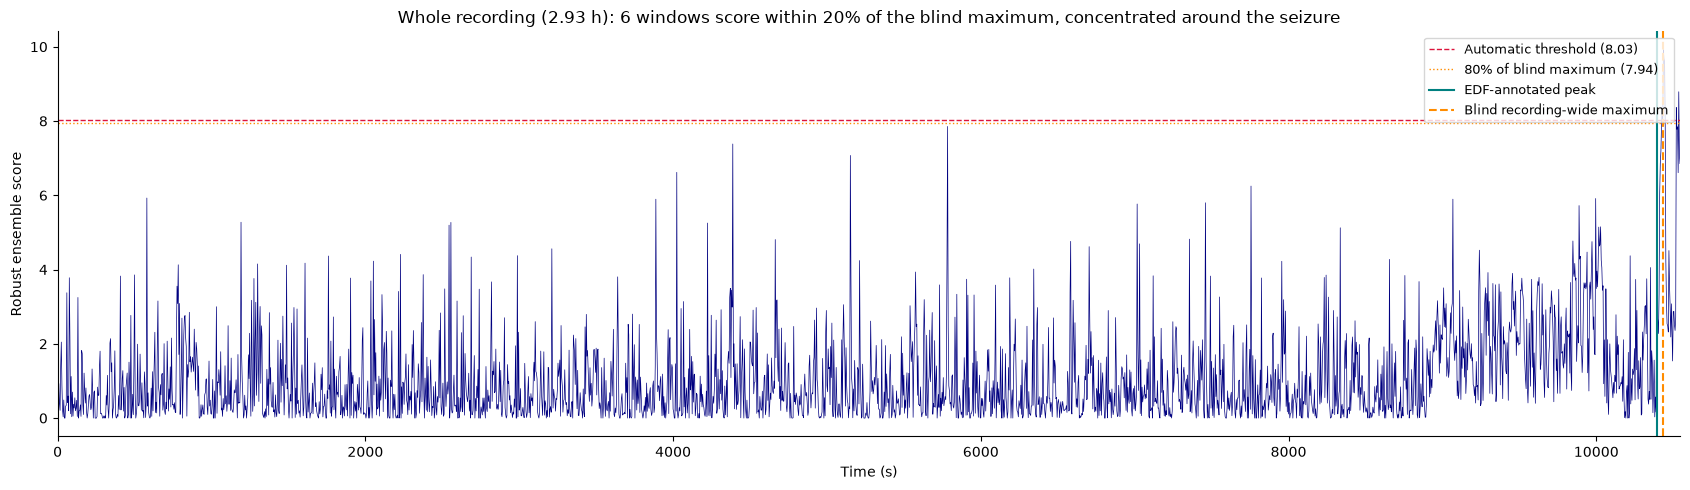

In [34]:
comparable_threshold = 0.8 * blind_max_score
comparable_mask = global_score >= comparable_threshold
n_comparable = int(np.sum(comparable_mask))
comparable_times = window_start_s[comparable_mask]

CONCENTRATION_WINDOW_SECONDS = 300.0  # generous post-ictal window for "near the seizure"
if n_comparable:
    span_s = float(comparable_times.max() - comparable_times.min())
    near_peak = np.abs(comparable_times - known_peak_seconds) <= CONCENTRATION_WINDOW_SECONDS
    concentrated_near_peak = bool(near_peak.all()) and span_s <= CONCENTRATION_WINDOW_SECONDS
else:
    span_s = 0.0
    concentrated_near_peak = False

print(f"Windows scoring within 20% of the blind maximum ({comparable_threshold:.2f}): "
      f"{n_comparable:,} of {len(global_score):,} "
      f"({100 * n_comparable / len(global_score):.2f}% of the recording).")
if n_comparable == 0:
    print("No window besides the maximum itself scores this high anywhere in the recording.")
elif concentrated_near_peak:
    print(f"All {n_comparable} of them fall within a {span_s:.0f} s span, "
          f"{abs(comparable_times.min() - known_peak_seconds):.0f}–"
          f"{abs(comparable_times.max() - known_peak_seconds):.0f} s from the EDF-annotated peak — "
          "concentrated around the seizure itself, not spread through the recording's interictal "
          "background. See the whole-recording plot below.")
else:
    print("If this method separated the seizure from the background, this count would be small "
          "and concentrated near the annotated peak; instead it is spread through the recording — "
          "see the whole-recording plot below.")

concentration_label = ("concentrated around the seizure" if concentrated_near_peak
                       else "scattered through the recording" if n_comparable else "unique to the maximum")

fig, ax = plt.subplots(figsize=(17, 5))
ax.plot(window_start_s, global_score, color="navy", linewidth=0.5)
ax.axhline(automatic_threshold, color="crimson", linestyle="--", linewidth=1,
          label=f"Automatic threshold ({automatic_threshold:.2f})")
ax.axhline(comparable_threshold, color="darkorange", linestyle=":", linewidth=1,
          label=f"80% of blind maximum ({comparable_threshold:.2f})")
ax.axvline(known_peak_seconds, color="teal", linewidth=1.5, label="EDF-annotated peak")
ax.axvline(blind_max_seconds, color="darkorange", linewidth=1.5, linestyle="--",
          label="Blind recording-wide maximum")
ax.set(xlabel="Time (s)", ylabel="Robust ensemble score",
      title=f"Whole recording ({duration_s / 3600:.2f} h): {n_comparable:,} windows score "
            f"within 20% of the blind maximum, {concentration_label}")
ax.legend(loc="upper right", fontsize=9)
ax.margins(x=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "whole_recording_blind_ensemble_score.png", dpi=160)
plt.show()


## 7. Part 1: zoomed view of both moments

A single, enlarged window spanning both the blind maximum and the annotated peak (`ZOOM_PADDING_SECONDS` on each side), so the two can be compared directly instead of read off two distant points on the whole-recording plot above: the top panel is the same ensemble score as Section 5, zoomed in; the bottom panel is the raw multichannel traces in that same window, normalized the same way `sEEG_extreme_event_detector_colab.ipynb` displays them. Unlike the raw-file version of this analysis (where the two moments were ~188 s apart, and the "moment" the blind scan actually flagged was inside the excluded cauterization segment), the top panel here shows one continuous rise starting almost exactly at the EDF-annotated peak and cresting 39.6 s later at the blind maximum: the ensemble is not missing this seizure, it is centering on its most intense (likely convulsive/tonic-clonic) phase rather than the clinical onset.


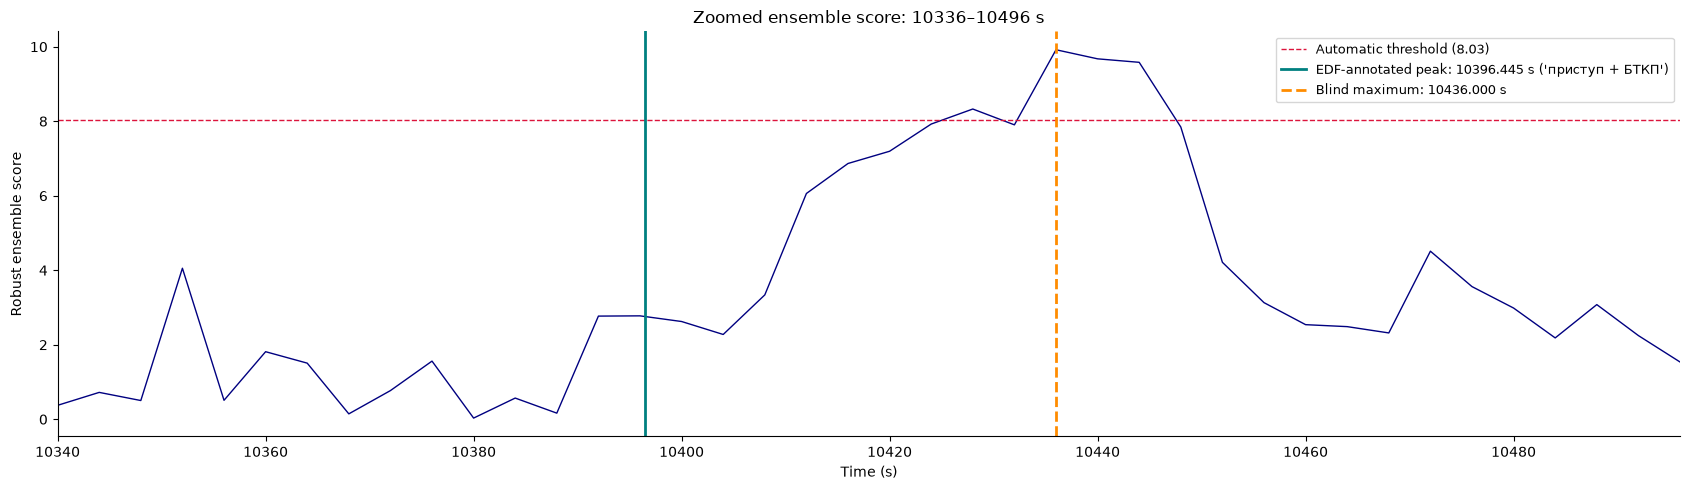

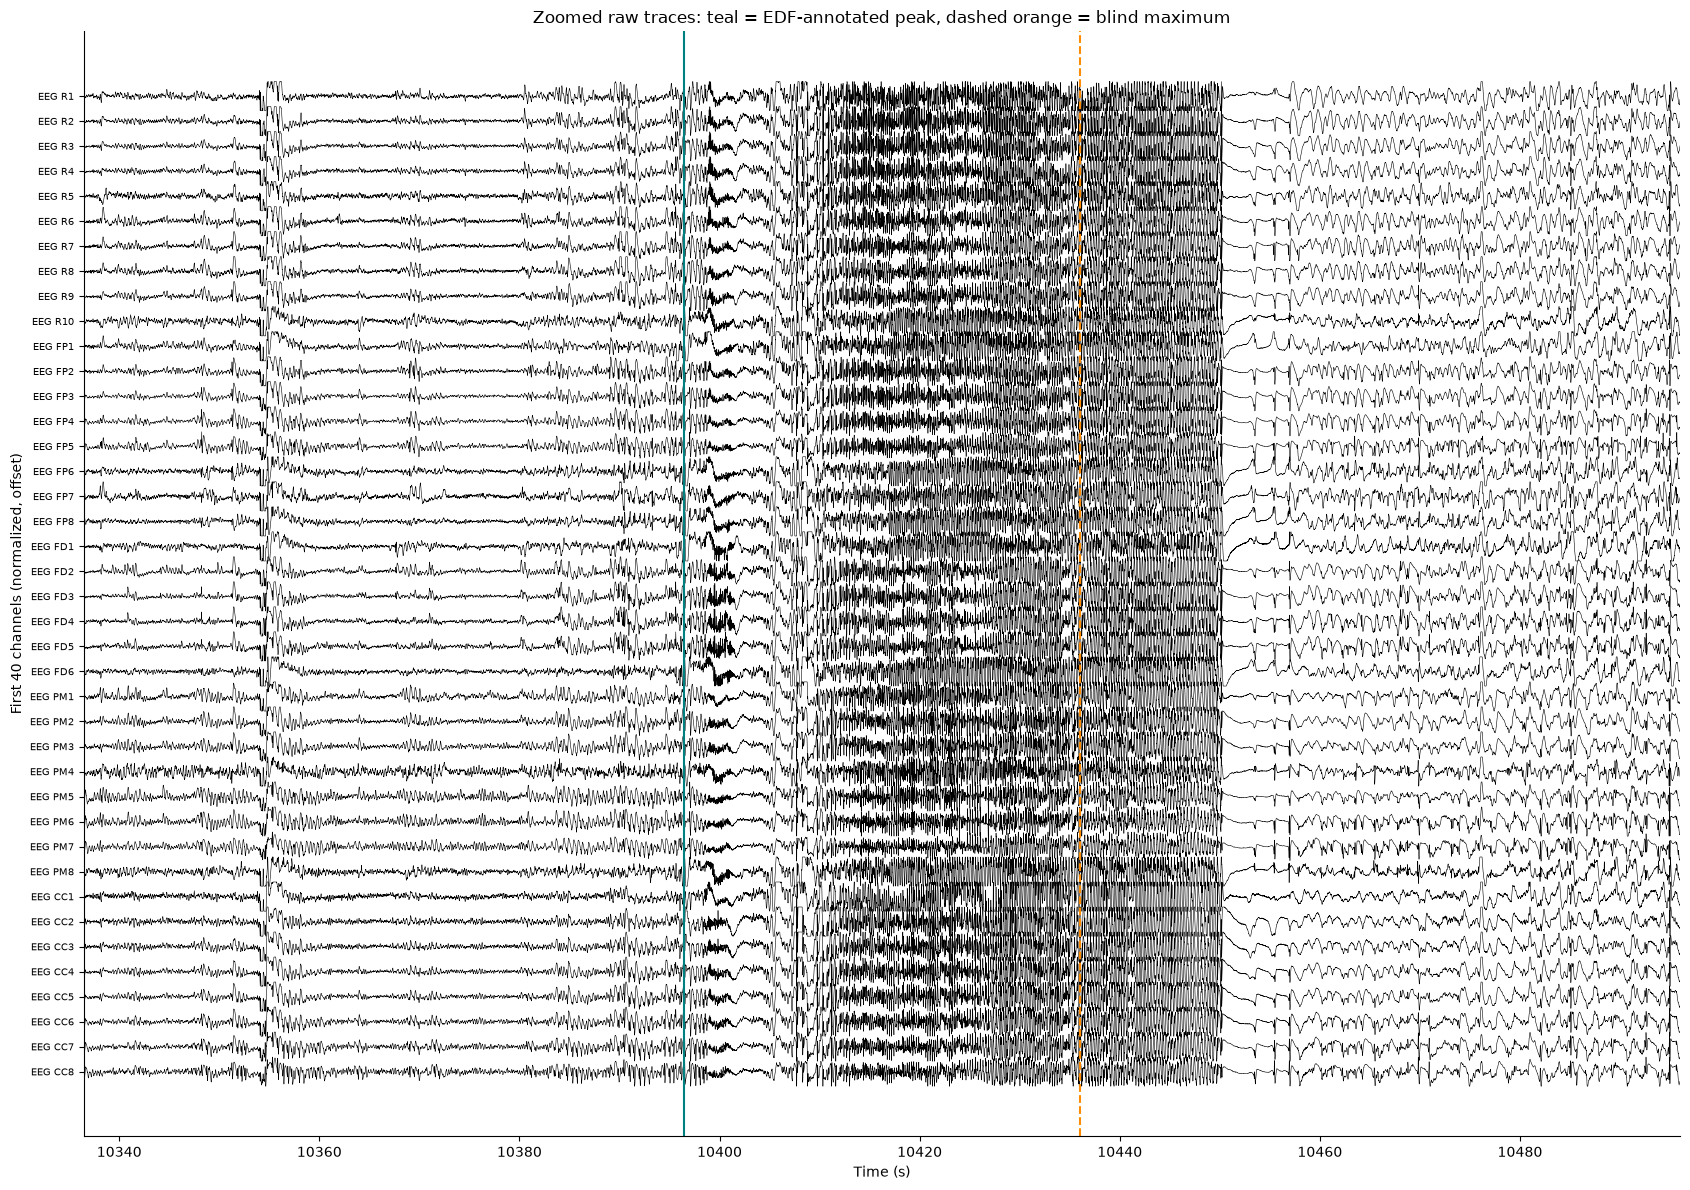

In [35]:
zoom_start_s = max(0.0, min(known_peak_seconds, blind_max_seconds) - ZOOM_PADDING_SECONDS)
zoom_end_s = min(duration_s, max(known_peak_seconds, blind_max_seconds) + ZOOM_PADDING_SECONDS)
zoom_mask = (window_start_s >= zoom_start_s) & (window_start_s <= zoom_end_s)

fig, ax = plt.subplots(figsize=(17, 5))
ax.plot(window_start_s[zoom_mask], global_score[zoom_mask], color="navy", linewidth=1.0)
ax.axhline(automatic_threshold, color="crimson", linestyle="--", linewidth=1,
           label=f"Automatic threshold ({automatic_threshold:.2f})")
ax.axvline(known_peak_seconds, color="teal", linewidth=2,
           label=f"EDF-annotated peak: {known_peak_seconds:.3f} s ({known_peak_label!r})")
ax.axvline(blind_max_seconds, color="darkorange", linewidth=2, linestyle="--",
           label=f"Blind maximum: {blind_max_seconds:.3f} s")
ax.set(xlabel="Time (s)", ylabel="Robust ensemble score",
      title=f"Zoomed ensemble score: {zoom_start_s:.0f}\u2013{zoom_end_s:.0f} s")
ax.legend(loc="upper right", fontsize=9)
ax.margins(x=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zoomed_blind_score_both_moments.png", dpi=160)
plt.show()

start_sample = int(np.floor(zoom_start_s * sfreq))
stop_sample = min(raw.n_times, int(np.ceil(zoom_end_s * sfreq)))
plot_channels = signal_channels[:MAX_PLOT_CHANNELS]
trace = raw.get_data(picks=plot_channels, start=start_sample, stop=stop_sample) * 1e6
trace_times = np.arange(start_sample, stop_sample) / sfreq
trace -= np.nanmedian(trace, axis=1, keepdims=True)
scale = 1.4826 * np.nanmedian(np.abs(trace), axis=1)
scale = np.where(scale > 0, scale, np.nanstd(trace, axis=1))
normalized_trace = trace / np.where(scale > 0, scale, 1)[:, None]
offsets = np.arange(len(plot_channels))[::-1] * 6.0

fig, ax = plt.subplots(figsize=(17, max(8, 0.3 * len(plot_channels))))
for values, offset in zip(normalized_trace, offsets):
    ax.plot(trace_times, np.clip(values, -3.5, 3.5) + offset, color="black", linewidth=0.4)
ax.axvline(known_peak_seconds, color="teal", linewidth=1.5)
ax.axvline(blind_max_seconds, color="darkorange", linewidth=1.5, linestyle="--")
ax.set_yticks(offsets, plot_channels, fontsize=7)
ax.set(xlabel="Time (s)", ylabel=f"First {len(plot_channels)} channels (normalized, offset)",
      title="Zoomed raw traces: teal = EDF-annotated peak, dashed orange = blind maximum")
ax.margins(x=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zoomed_traces_both_moments.png", dpi=160)
plt.show()


## 8. Part 3: the targeted method that does find it — precisely

Not a different statistical trick on the same broadband features — a different *feature*: sliding 250 ms energy restricted to 13–80 Hz (beta/gamma), the band the clinical context for this recording specifically implicates, standardized against a pre-event baseline with median/MAD (so "unusual" is relative to each channel's own quiet period, not the whole recording), computed only in a window around Section 4's annotated peak — not blindly across the whole recording. This mirrors `extreme_event_agent.edf_workflow._beta_gamma_z_scores` in the installable package.


Targeted beta/gamma (13–80 Hz) analysis, window 10366.4–10406.9 s:
  98 of 100 channels cross 6 MAD above baseline within 10 s of the annotated peak (98% of the montage).
  Compare: the blind broadband scan (Sections 5–6) stays below its own automatic threshold for the entirety of this window, and only crosses it 39.6 s after the annotated onset -- well past this window's 10.5 s right edge.


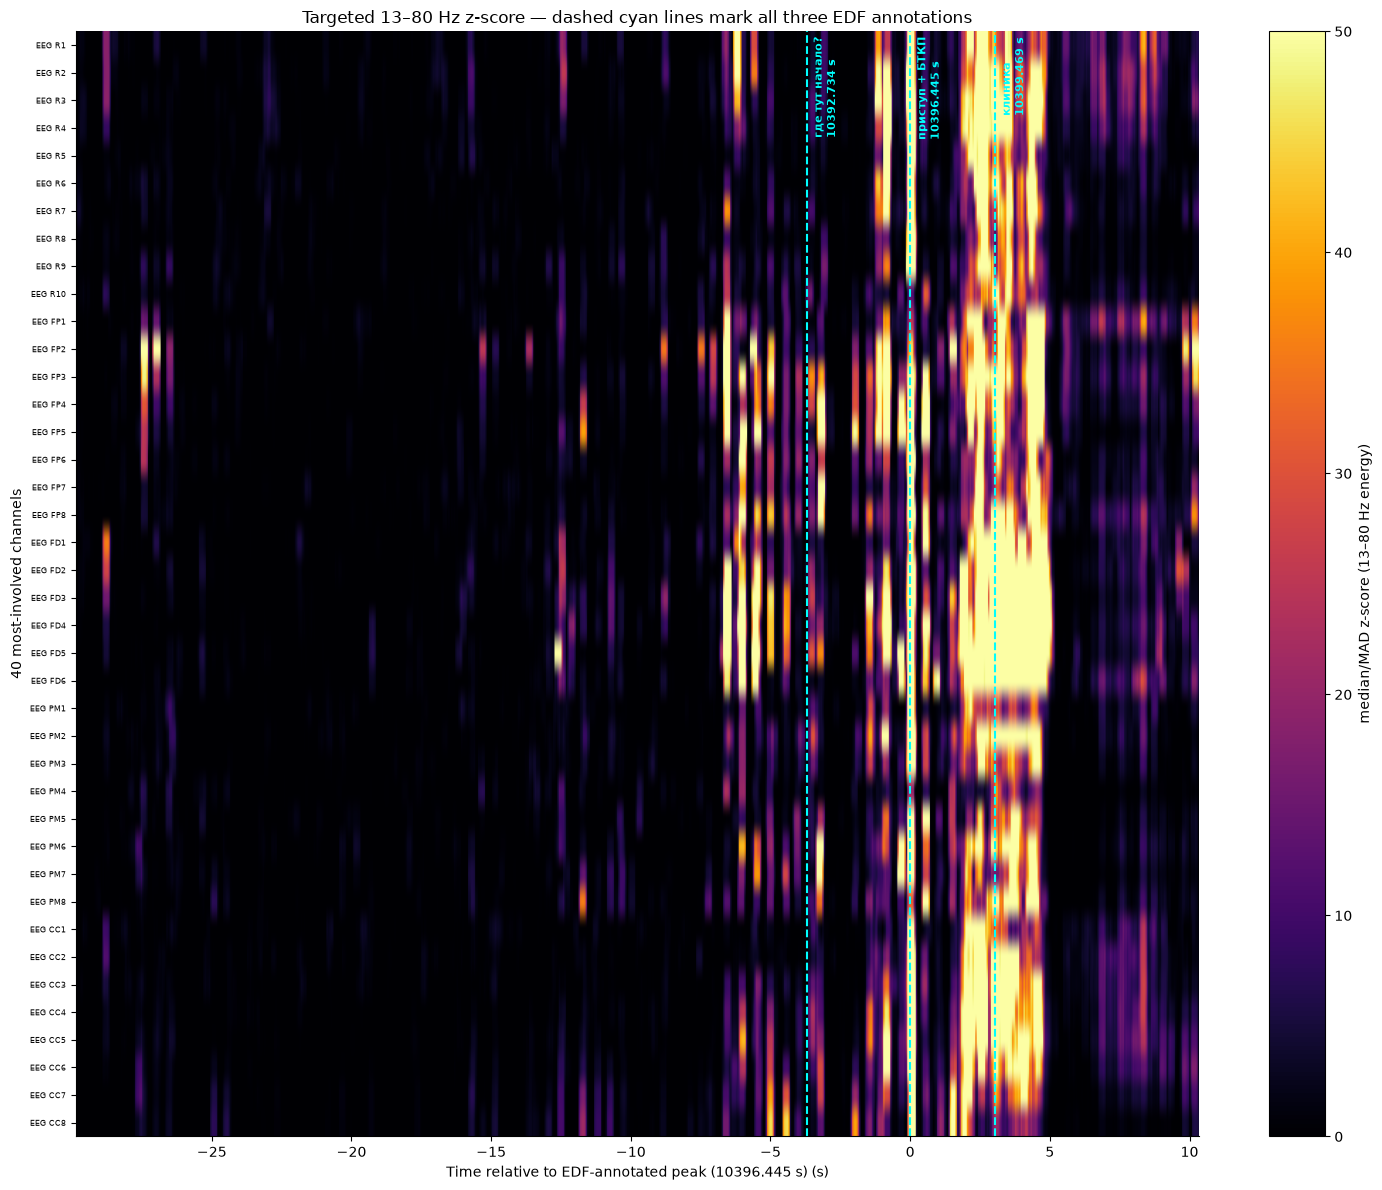

In [36]:
context_start_s = max(0.0, known_peak_seconds - TARGETED_BASELINE_SECONDS)
context_end_s = min(duration_s, known_peak_seconds + TARGETED_ANALYSIS_SECONDS + 0.5)
first_sample = int(np.floor(context_start_s * sfreq))
last_sample = int(np.ceil(context_end_s * sfreq))
context = raw.get_data(picks=signal_channels, start=first_sample, stop=last_sample) * 1e6

high_hz = min(80.0, sfreq / 2 * 0.95)
sos = butter(4, [13.0, high_hz], btype="bandpass", fs=sfreq, output="sos")
filtered = sosfiltfilt(sos, np.nan_to_num(context), axis=1)

win_samples = max(4, round(0.25 * sfreq))
step_samples_targeted = max(1, round(0.05 * sfreq))
starts = np.arange(0, filtered.shape[1] - win_samples + 1, step_samples_targeted)
targeted_times = context_start_s + (starts + win_samples / 2) / sfreq
energy = np.stack([np.mean(filtered[:, s:s + win_samples] ** 2, axis=1) for s in starts])

baseline_mask = (targeted_times >= context_start_s) & (targeted_times < known_peak_seconds)
center = np.median(energy[baseline_mask], axis=0)
mad = 1.4826 * np.median(np.abs(energy[baseline_mask] - center), axis=0)
scale = np.where(mad > 1e-20, mad, np.maximum(np.std(energy[baseline_mask], axis=0), 1e-20))
targeted_z = np.clip((energy - center) / scale, 0, 50)

after_mask = (targeted_times >= known_peak_seconds) & (targeted_times <= known_peak_seconds + TARGETED_ANALYSIS_SECONDS)
peak_scores = np.max(targeted_z[after_mask], axis=0)
latency = {}
for index, name in enumerate(signal_channels):
    crossings = np.flatnonzero(after_mask & (targeted_z[:, index] >= 6.0))
    if crossings.size:
        latency[name] = float(targeted_times[crossings[0]] - known_peak_seconds)

n_involved = len(latency)
print(f"Targeted beta/gamma (13–{high_hz:.0f} Hz) analysis, window "
      f"{context_start_s:.1f}–{context_end_s:.1f} s:")
print(f"  {n_involved} of {len(signal_channels)} channels cross 6 MAD above baseline "
      f"within {TARGETED_ANALYSIS_SECONDS:.0f} s of the annotated peak "
      f"({100 * n_involved / len(signal_channels):.0f}% of the montage).")
print(f"  Compare: the blind broadband scan (Sections 5–6) stays below its own automatic "
      f"threshold for the entirety of this window, and only crosses it "
      f"{blind_max_seconds - known_peak_seconds:.1f} s after the annotated onset -- "
      f"well past this window's {context_end_s - known_peak_seconds:.1f} s right edge.")

order = sorted(latency, key=latency.get) if latency else sorted(
    range(len(signal_channels)), key=lambda i: -peak_scores[i])[:MAX_PLOT_CHANNELS]
if latency:
    order = order[:MAX_PLOT_CHANNELS] if len(order) > MAX_PLOT_CHANNELS else order
    plot_names = order
else:
    plot_names = [signal_channels[i] for i in order]
plot_indices = [signal_channels.index(name) for name in plot_names] if latency else order
matrix = targeted_z[:, plot_indices].T
relative_times = targeted_times - known_peak_seconds

fig, ax = plt.subplots(figsize=(15, max(6, 0.3 * len(plot_indices))))
im = ax.imshow(matrix, aspect="auto", cmap="inferno", vmin=0, vmax=max(6.0, float(np.percentile(matrix, 99))),
               extent=[relative_times[0], relative_times[-1], len(plot_indices), 0])
label_names = plot_names if latency else [signal_channels[i] for i in plot_indices]
ax.set_yticks(np.arange(len(plot_indices)) + 0.5, label_names, fontsize=6)
colors_by_label = {known_peak_cluster[i][0]: c for i, c in
                   enumerate(["#8ecae6", "#ffffff", "#ffb703"][:len(known_peak_cluster)])}
for onset, description in known_peak_cluster:
    ax.axvline(onset - known_peak_seconds, color="cyan", linewidth=1.5, linestyle="--")
    ax.annotate(f"{description}\n{onset:.3f} s", (onset - known_peak_seconds, 0),
               xytext=(4, -4), textcoords="offset points", color="cyan", fontsize=8,
               fontweight="bold", va="top", rotation=90)
ax.set_xlabel(f"Time relative to EDF-annotated peak ({known_peak_seconds:.3f} s) (s)")
ax.set_ylabel(f"{len(plot_indices)} most-involved channels")
ax.set_title("Targeted 13–80 Hz z-score — dashed cyan lines mark all three EDF annotations")
colorbar = fig.colorbar(im, ax=ax)
colorbar.set_label("median/MAD z-score (13–80 Hz energy)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "targeted_beta_gamma_heatmap.png", dpi=160)
plt.show()


## 9. Conclusion: data hygiene changes the outcome; precision, not raw detectability, is the real boundary

Two things are demonstrated here, not one.

**First, data hygiene matters as much as method choice.** Scanning this file end to end — including ≈59 min of a post-seizure surgical cauterization procedure that is not brain activity — made the blind ensemble both miss the seizure (`detected=False`) *and* report a confident-looking but meaningless recording-wide maximum sitting inside the cauterization segment itself. That one non-physiological excursion did double damage: it became the reported "detection", and it inflated the recording's own median/MAD statistics enough to push the automatic threshold above the genuine seizure-related signal. Excluding the non-brain segment before any analysis (Section 3) removes both problems at once — with no change to the ensemble, its features, or its threshold rule, `detected` goes from `False` to `True` and the automatic threshold drops from 20.25 to 8.03.

**Second, even on the cleaned recording, the blind broadband ensemble is imprecise, not blind.** Its recording-wide maximum lands 39.6 s after the EDF-annotated onset, most likely on the seizure's convulsive/tonic-clonic phase rather than the clinical onset itself, and every one of the handful of comparably-scoring windows (6 of 2637, all within a 108 s span) sits in that same post-onset stretch — a real, if late and coarse, signal, not interictal noise masquerading as one. What the blind ensemble cannot do is what Section 8's targeted, band-restricted, annotation-anchored method does well: pinpoint the onset to within seconds and identify that 98 of 100 contacts are involved. That gap — latency and spatial/spectral specificity, not raw separability — is the applicability boundary this recording actually supports. A purely statistical outlier detector built on broadband features (this ensemble, a One-Class SVM, a local-neighbor-density method) can be expected to hit the same ceiling: coarse, delayed flags rather than precise, interpretable ones — a materially different and weaker claim than "cannot find it at all", which only held here because the recording had not yet been restricted to genuine brain activity.

**Not a diagnosis.** Every output above is a research candidate for expert review against the raw EDF, montage, video, and clinical record — not a clinical device.
